In [9]:
# =============================================
# 04_Explainability_and_Interventions.ipynb
# Student At-Risk Prediction Project
# =============================================
# Install SHAP (Run this cell)
!pip install shap -q

print("✅ SHAP installed successfully!")

import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries Imported!")

✅ SHAP installed successfully!
✅ Libraries Imported!


In [10]:
# Load the best model and data
model = joblib.load('xgboost_atrisk_improved.pkl')        # Best one (87.88%)
df_clean = pd.read_csv('data/cleaned_student_data.csv')
df = pd.read_csv('data/processed_student_data.csv')       # Original for reference

print("✅ Model and Data Loaded!")
print("Number of Features:", df_clean.shape[1])

✅ Model and Data Loaded!
Number of Features: 45


In [11]:
# =============================================
# SHAP EXPLAINABILITY
# =============================================

# Prepare data for SHAP
X = df_clean.copy()
y = df['at_risk']

# Split for explanation
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Create SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP Values Calculated!")

✅ SHAP Values Calculated!


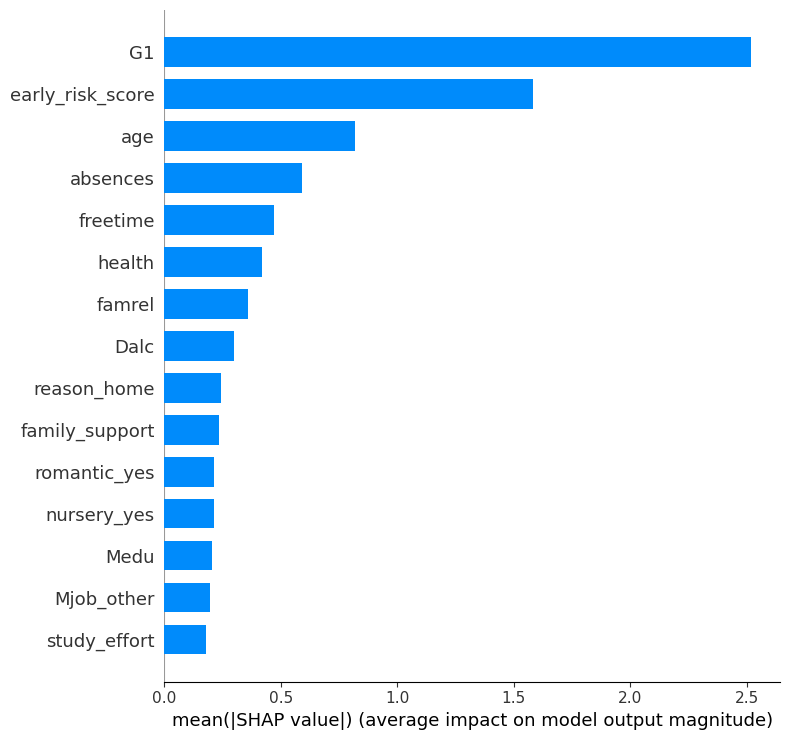

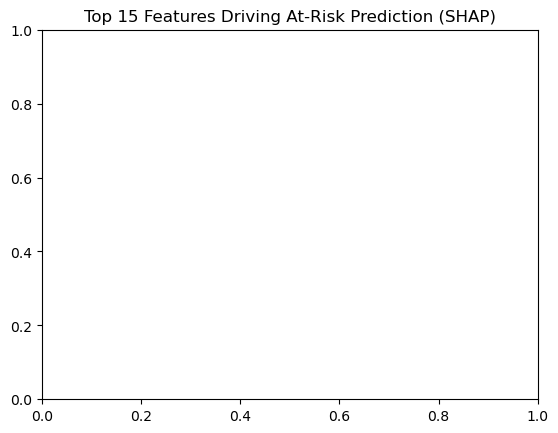

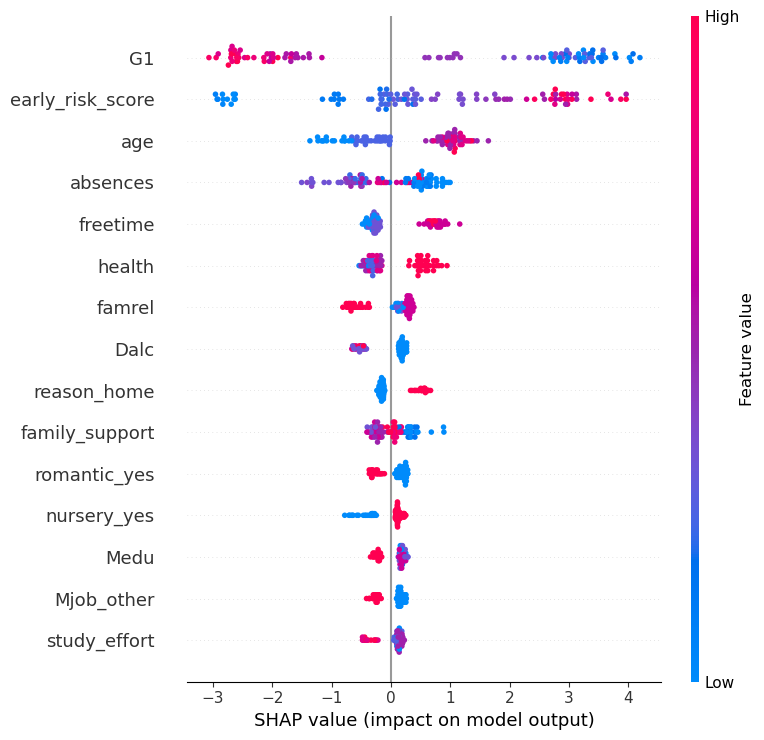

In [12]:
# 1. Global Feature Importance (Bar Plot)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15)
plt.title("Top 15 Features Driving At-Risk Prediction (SHAP)")
plt.show()

# 2. SHAP Summary Plot (Beeswarm)
shap.summary_plot(shap_values, X_test, max_display=15)
plt.show()

In [13]:
# =============================================
# PERSONALIZED INTERVENTION SYSTEM
# =============================================

def generate_personalized_intervention(student_idx):
    student = X_test.iloc[student_idx]
    shap_val = shap_values[student_idx]
    risk_prob = model.predict_proba(X_test.iloc[[student_idx]])[0, 1]
    
    print(f"🎯 Student Index: {student_idx}")
    print(f"Risk Probability: {risk_prob:.1%} → {'HIGH RISK' if risk_prob > 0.5 else 'Low Risk'}\n")
    print("📋 Personalized Intervention Plan:\n")
    
    # Get top contributing features
    feature_impact = pd.Series(shap_val, index=X_test.columns).abs().sort_values(ascending=False)
    top_features = feature_impact.head(6)
    
    interventions = []
    
    for feat, impact in top_features.items():
        value = student[feat]
        
        if 'absences' in feat and value > 8:
            interventions.append("🔴 High Absences → Immediate Attendance Counseling + Parent Meeting")
        elif 'failures' in feat and value > 0:
            interventions.append("🔴 Past Failures → Extra Remedial Classes + Progress Tracking")
        elif 'studytime' in feat and value <= 2:
            interventions.append("🔴 Low Study Time → Daily Study Schedule + Academic Mentor")
        elif 'early_risk_score' in feat:
            interventions.append("🔴 Early Risk Signals → Faculty Advisor Meeting within 3 days")
        elif 'family_support' in feat and value < 8:
            interventions.append("🔴 Low Family Support → Family Counseling Session")
        elif 'total_alcohol' in feat and value >= 6:
            interventions.append("🔴 High Alcohol Consumption → Counseling & Awareness Program")
        else:
            interventions.append(f"⚠️  {feat.replace('_', ' ').title()} → Special Attention Needed")
    
    for inter in interventions:
        print(inter)
    
    print("\n📌 Recommendation: Schedule meeting with faculty/HOD within 48 hours.")

# Example: Generate for 3 different students
print("=== EXAMPLE INTERVENTIONS ===\n")
for i in [0, 5, 10]:
    generate_personalized_intervention(i)
    print("-" * 60)

=== EXAMPLE INTERVENTIONS ===

🎯 Student Index: 0
Risk Probability: 98.6% → HIGH RISK

📋 Personalized Intervention Plan:

⚠️  G1 → Special Attention Needed
⚠️  Age → Special Attention Needed
⚠️  Nursery Yes → Special Attention Needed
⚠️  Absences → Special Attention Needed
⚠️  Reason Home → Special Attention Needed
⚠️  Health → Special Attention Needed

📌 Recommendation: Schedule meeting with faculty/HOD within 48 hours.
------------------------------------------------------------
🎯 Student Index: 5
Risk Probability: 99.9% → HIGH RISK

📋 Personalized Intervention Plan:

⚠️  G1 → Special Attention Needed
🔴 Early Risk Signals → Faculty Advisor Meeting within 3 days
⚠️  Freetime → Special Attention Needed
⚠️  Age → Special Attention Needed
⚠️  Romantic Yes → Special Attention Needed
⚠️  Medu → Special Attention Needed

📌 Recommendation: Schedule meeting with faculty/HOD within 48 hours.
------------------------------------------------------------
🎯 Student Index: 10
Risk Probability: 98.3

In [14]:
def predict_student_risk(new_student_dict):
    """
    Predict if a new student is at-risk and generate explanation + intervention
    """
    # Convert input dictionary to DataFrame
    new_df = pd.DataFrame([new_student_dict])
    
    # Apply same feature engineering
    new_df['total_alcohol'] = new_df['Dalc'] + new_df['Walc']
    new_df['study_effort'] = new_df['studytime'] - new_df['failures']
    new_df['family_support'] = new_df['Medu'] + new_df['Fedu'] + new_df['famrel']
    new_df['early_risk_score'] = new_df['absences'] + (new_df['failures'] * 5) - new_df['G1']
    new_df['social_activity'] = new_df['freetime'] + new_df['goout']
    
    # One-hot encoding (must match training columns)
    categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 
                        'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 
                        'famsup', 'paid', 'activities', 'nursery', 'higher', 
                        'internet', 'romantic']
    
    new_df_encoded = pd.get_dummies(new_df, columns=categorical_cols, drop_first=True)
    
    # Align columns with training data
    training_cols = model.feature_names_in_ if hasattr(model, 'feature_names_in_') else df_clean.columns
    for col in training_cols:
        if col not in new_df_encoded.columns:
            new_df_encoded[col] = 0
    
    new_df_encoded = new_df_encoded[training_cols]
    
    # Make Prediction
    risk_prob = model.predict_proba(new_df_encoded)[0, 1]
    prediction = model.predict(new_df_encoded)[0]
    
    print("="*60)
    print("🎯 STUDENT RISK PREDICTION")
    print("="*60)
    print(f"Risk Probability : {risk_prob:.1%}")
    print(f"Prediction       : {'🔴 HIGH RISK' if prediction == 1 else '🟢 Low Risk'}")
    print("="*60)
    
    # Generate Intervention
    print("\n📋 Personalized Intervention Recommendations:")
    print("-" * 50)
    
    if risk_prob > 0.7:
        print("🚨 Immediate Action Required:")
        print("• Schedule meeting with HOD/Faculty within 24 hours")
        print("• Assign Academic Mentor")
        print("• Parent-Teacher Meeting")
    elif risk_prob > 0.5:
        print("⚠️  Moderate Risk - Early Intervention:")
        print("• Extra classes / Remedial sessions")
        print("• Regular attendance monitoring")
        print("• Study plan adjustment")
    else:
        print("✅ Low Risk - Monitor Only")
        print("• Continue regular follow-up")
    
    return {
        "risk_probability": risk_prob,
        "at_risk": bool(prediction),
        "recommendation_level": "High" if risk_prob > 0.7 else "Medium" if risk_prob > 0.5 else "Low"
    }
   

In [15]:
# =============================================
# TEST PREDICTION - NEW STUDENT
# =============================================

# Define a new student (you can change these values)
new_student = {
    'school': 'GP',
    'sex': 'F',
    'age': 17,
    'address': 'U',
    'famsize': 'GT3',
    'Pstatus': 'T',
    'Medu': 2,
    'Fedu': 1,
    'Mjob': 'other',
    'Fjob': 'other',
    'reason': 'course',
    'guardian': 'mother',
    'traveltime': 1,
    'studytime': 1,          # Low study time
    'failures': 1,
    'schoolsup': 'no',
    'famsup': 'yes',
    'paid': 'no',
    'activities': 'no',
    'nursery': 'yes',
    'higher': 'yes',
    'internet': 'yes',
    'romantic': 'no',
    'famrel': 3,
    'freetime': 2,
    'goout': 4,
    'Dalc': 2,
    'Walc': 3,
    'health': 4,
    'absences': 12,          # High absences
    'G1': 6,
}

# Make Prediction
result = predict_student_risk(new_student)

🎯 STUDENT RISK PREDICTION
Risk Probability : 99.9%
Prediction       : 🔴 HIGH RISK

📋 Personalized Intervention Recommendations:
--------------------------------------------------
🚨 Immediate Action Required:
• Schedule meeting with HOD/Faculty within 24 hours
• Assign Academic Mentor
• Parent-Teacher Meeting
